# Cenozoic ocean gateways

**Cluster J: Paleoclimate.**  *Dataset:* Straume, E.O. et al. (2020), *Global and Planetary Change* -- global paleobathymetry/topography grids at 1-Myr-to-5-Myr cadence, 0-65 Ma, purpose-built to resolve the opening, deepening, and closing of four Northern Hemisphere ocean gateways that repeatedly reorganised Cenozoic ocean circulation.

A gateway's *bathymetry* -- is it open water, and how deep -- is only half the story. The other half is *why* it changes: seafloor spreading opening a new strait, a ridge crest subsiding as it ages and moves away from a spreading centre, a subduction zone closing a seaway by driving arc-continent collision. Straume et al.'s own reconstruction is explicitly built as "an update of the global kinematic model of Seton et al. (2012)" -- so the same plate-tectonic framework that predicts *where* Straume's bathymetry values sit also predicts *why* they change, if reconstructed independently. This notebook does exactly that: it takes Straume's real, independently-derived bathymetry grids at face value, then reconstructs Seton et al. (2012)'s plate boundaries (mid-ocean ridges, transforms, subduction zones) with `gplately` at the same ages, and overlays the two to see whether the tectonic mechanism actually lines up with the observed bathymetric change.

**A disclosed limitation, up front.** Straume et al. (2020) do not appear to have released their own regional gateway-scale rotation/topology refinements as a separately downloadable GPlates model -- only the derived bathymetry/topography grids used here are archived on Zenodo. `plate_model_manager`'s model catalogue has no entry for a "Straume" model, and no separately published one turned up in GPlates' own hosted model list either. So the plate-boundary reconstruction used throughout this notebook is the paper's own explicitly-named *parent* model, Seton et al. (2012), not a Straume-specific refinement -- close enough to be genuinely informative about *first-order* tectonic mechanism (which plate boundary sits where, and when), but not a substitute for whatever finer within-strait detail Straume's own unpublished refinements might add. That trade-off is real and is not hidden anywhere in what follows.

## What this notebook produces

1. **&sect;1 -- Load the Straume bathymetry grids** and get oriented: what do they cover, and at what cadence.
2. **&sect;2 -- Global context.** The whole grid at the oldest (65 Ma) and youngest (1 Ma) available ages, with the four gateway regions marked.
3. **&sect;3 -- Reconstructing the tectonic mechanism.** At 34 Ma (the Eocene-Oligocene transition -- a genuinely major, well-established Cenozoic climate boundary), overlay `gplately`/Seton et al. (2012) plate boundaries (ridges, transforms, trenches) on each gateway's real Straume bathymetry, to see whether the tectonic setting explains the observed depth.
4. **&sect;4 -- Quantifying gateway evolution through time.** Mean elevation and percent-submerged within each gateway's region, computed at all 15 available ages (65-1 Ma), to trace each gateway's opening/deepening/closing history quantitatively rather than from single snapshots alone.
5. **&sect;5 -- What this does (and does not) show** about the four gateways' distinct Cenozoic histories.

## Learning objectives

- Combine an independently-derived, real paleobathymetry compilation with an independently-reconstructed plate-boundary model to test whether the two agree on mechanism -- neither dataset was built to match the other in advance.
- Recognise, and work honestly around, a common real-world limitation: the plate model a published reconstruction explicitly says it's "based on" is not always the exact model available for reuse; falling back to the stated parent model is a disclosed approximation, not silent substitution.
- Reduce a large gridded time series (15 ages x 6.5M grid cells each) to a small number of physically meaningful regional summary statistics (mean elevation, percent submerged), and read a multi-gateway comparison off the resulting time series.
- Read Cenozoic gateway bathymetric history in light of established plate-tectonic mechanisms (seafloor spreading, ridge subsidence, subduction-driven closure) rather than treating it as an unexplained empirical curve.

## Prerequisites and runtime

- **Bathymetry data**: Straume, E.O., Gaina, C., Medvedev, S. et al. (2020). *Global and Planetary Change* 194, 103297. 15 grids, 0.1&deg; resolution, 1-65 Ma, `zenodo_data/gateway_reconstruction_Straume2020/` (241 MB, not bundled in git -- see `zenodo_data/README.md`). Archived at https://doi.org/10.5281/zenodo.4193576 (v2.0), CC BY 4.0.
- **Plate model**: Seton et al. (2012) -- the explicitly-named parent model of Straume et al.'s own reconstruction (see the limitation note above). Used only for plate-boundary/coastline context, never to alter or recompute Straume's bathymetry values themselves.
- **Python**: `gplately`, `pygmt`, `pygplates`, `plate_model_manager`, `xarray`, `numpy`, `pandas`.
- **Runtime**: ~2-3 min (dominated by reading 15 x 26 MB NetCDF grids).


## Environment + imports

In [1]:
from pathlib import Path
import os, sys

_nb_dir = Path(".").resolve()  # this notebook's own folder, captured before any chdir (data_check.py lives here)
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

sys.path.insert(0, str(_nb_dir))  # data_check.py lives alongside this notebook
from data_check import require_data
require_data(["zenodo_data/gateway_reconstruction_Straume2020/"])

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', getattr(_m, 'version', 'n/a'))}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME = "seton2012"  # Straume et al.'s own stated parent model (see limitation note above)
SNAPSHOT_AGE = 34.0        # Ma -- Eocene-Oligocene transition, used for the plate-boundary overlay

DATA_DIR = Path("zenodo_data/gateway_reconstruction_Straume2020")
AGES = [1.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 34.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0]

# Generous present-day-frame bounding boxes -- deliberately wide enough to contain each
# gateway across the full 0-65 Ma window even as the surrounding plates drift. This is a
# real simplification: it works well for the two North Atlantic-Arctic gateways below,
# where Cenozoic plate motion is modest, and more approximately for the two lower-latitude
# gateways, where it is not (see the discussion in \u00a73).
GATEWAYS = {
    "Fram Strait":               {"lon": (-20, 20), "lat": (72, 82)},
    "Greenland-Scotland Ridge":  {"lon": (-45, 0),  "lat": (58, 68)},
    "Central American Seaway":   {"lon": (-92, -70), "lat": (3, 15)},
    "Tethyan Seaway":            {"lon": (30, 65),   "lat": (10, 35)},
}
GATEWAY_COLOURS = {"Fram Strait": "steelblue", "Greenland-Scotland Ridge": "firebrick",
                    "Central American Seaway": "darkorange", "Tethyan Seaway": "seagreen"}

REGION = "d"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Load the Straume bathymetry grids

Each file is a single global 0.1&deg; grid (`z`, metres -- negative below sea level, positive land elevation) for one reconstruction age, already expressed in the paleo (reconstructed) reference frame -- i.e. each grid is a snapshot of what the world looked like at that age, not today's coastlines re-coloured.

In [3]:
def load_grid(age):
    fn = DATA_DIR / f"paleobathy-topo_{age:.2f}Ma_Straume_et_al.nc"
    return xr.open_dataset(fn)["z"]

_sample = load_grid(1.0)
print(f"  {len(AGES)} ages available, {min(AGES):.0f}-{max(AGES):.0f} Ma")
print(f"  grid shape {_sample.shape} (lat x lon), resolution "
      f"{float(_sample['lat'][1] - _sample['lat'][0]):.2f} deg")
print(f"  elevation range in the 1 Ma grid: {float(_sample.min()):.0f} to {float(_sample.max()):.0f} m")


  15 ages available, 1-65 Ma
  grid shape (1801, 3601) (lat x lon), resolution 0.10 deg
  elevation range in the 1 Ma grid: -5929 to 8000 m


  elevation range in the 1 Ma grid: -5929 to 8000 m


## 2. Global context: the oldest and youngest available ages

The full paleobathymetry at 65 Ma (right after the Cretaceous-Paleogene boundary) and 1 Ma (essentially present-day), with the four gateway regions from the configuration cell marked.

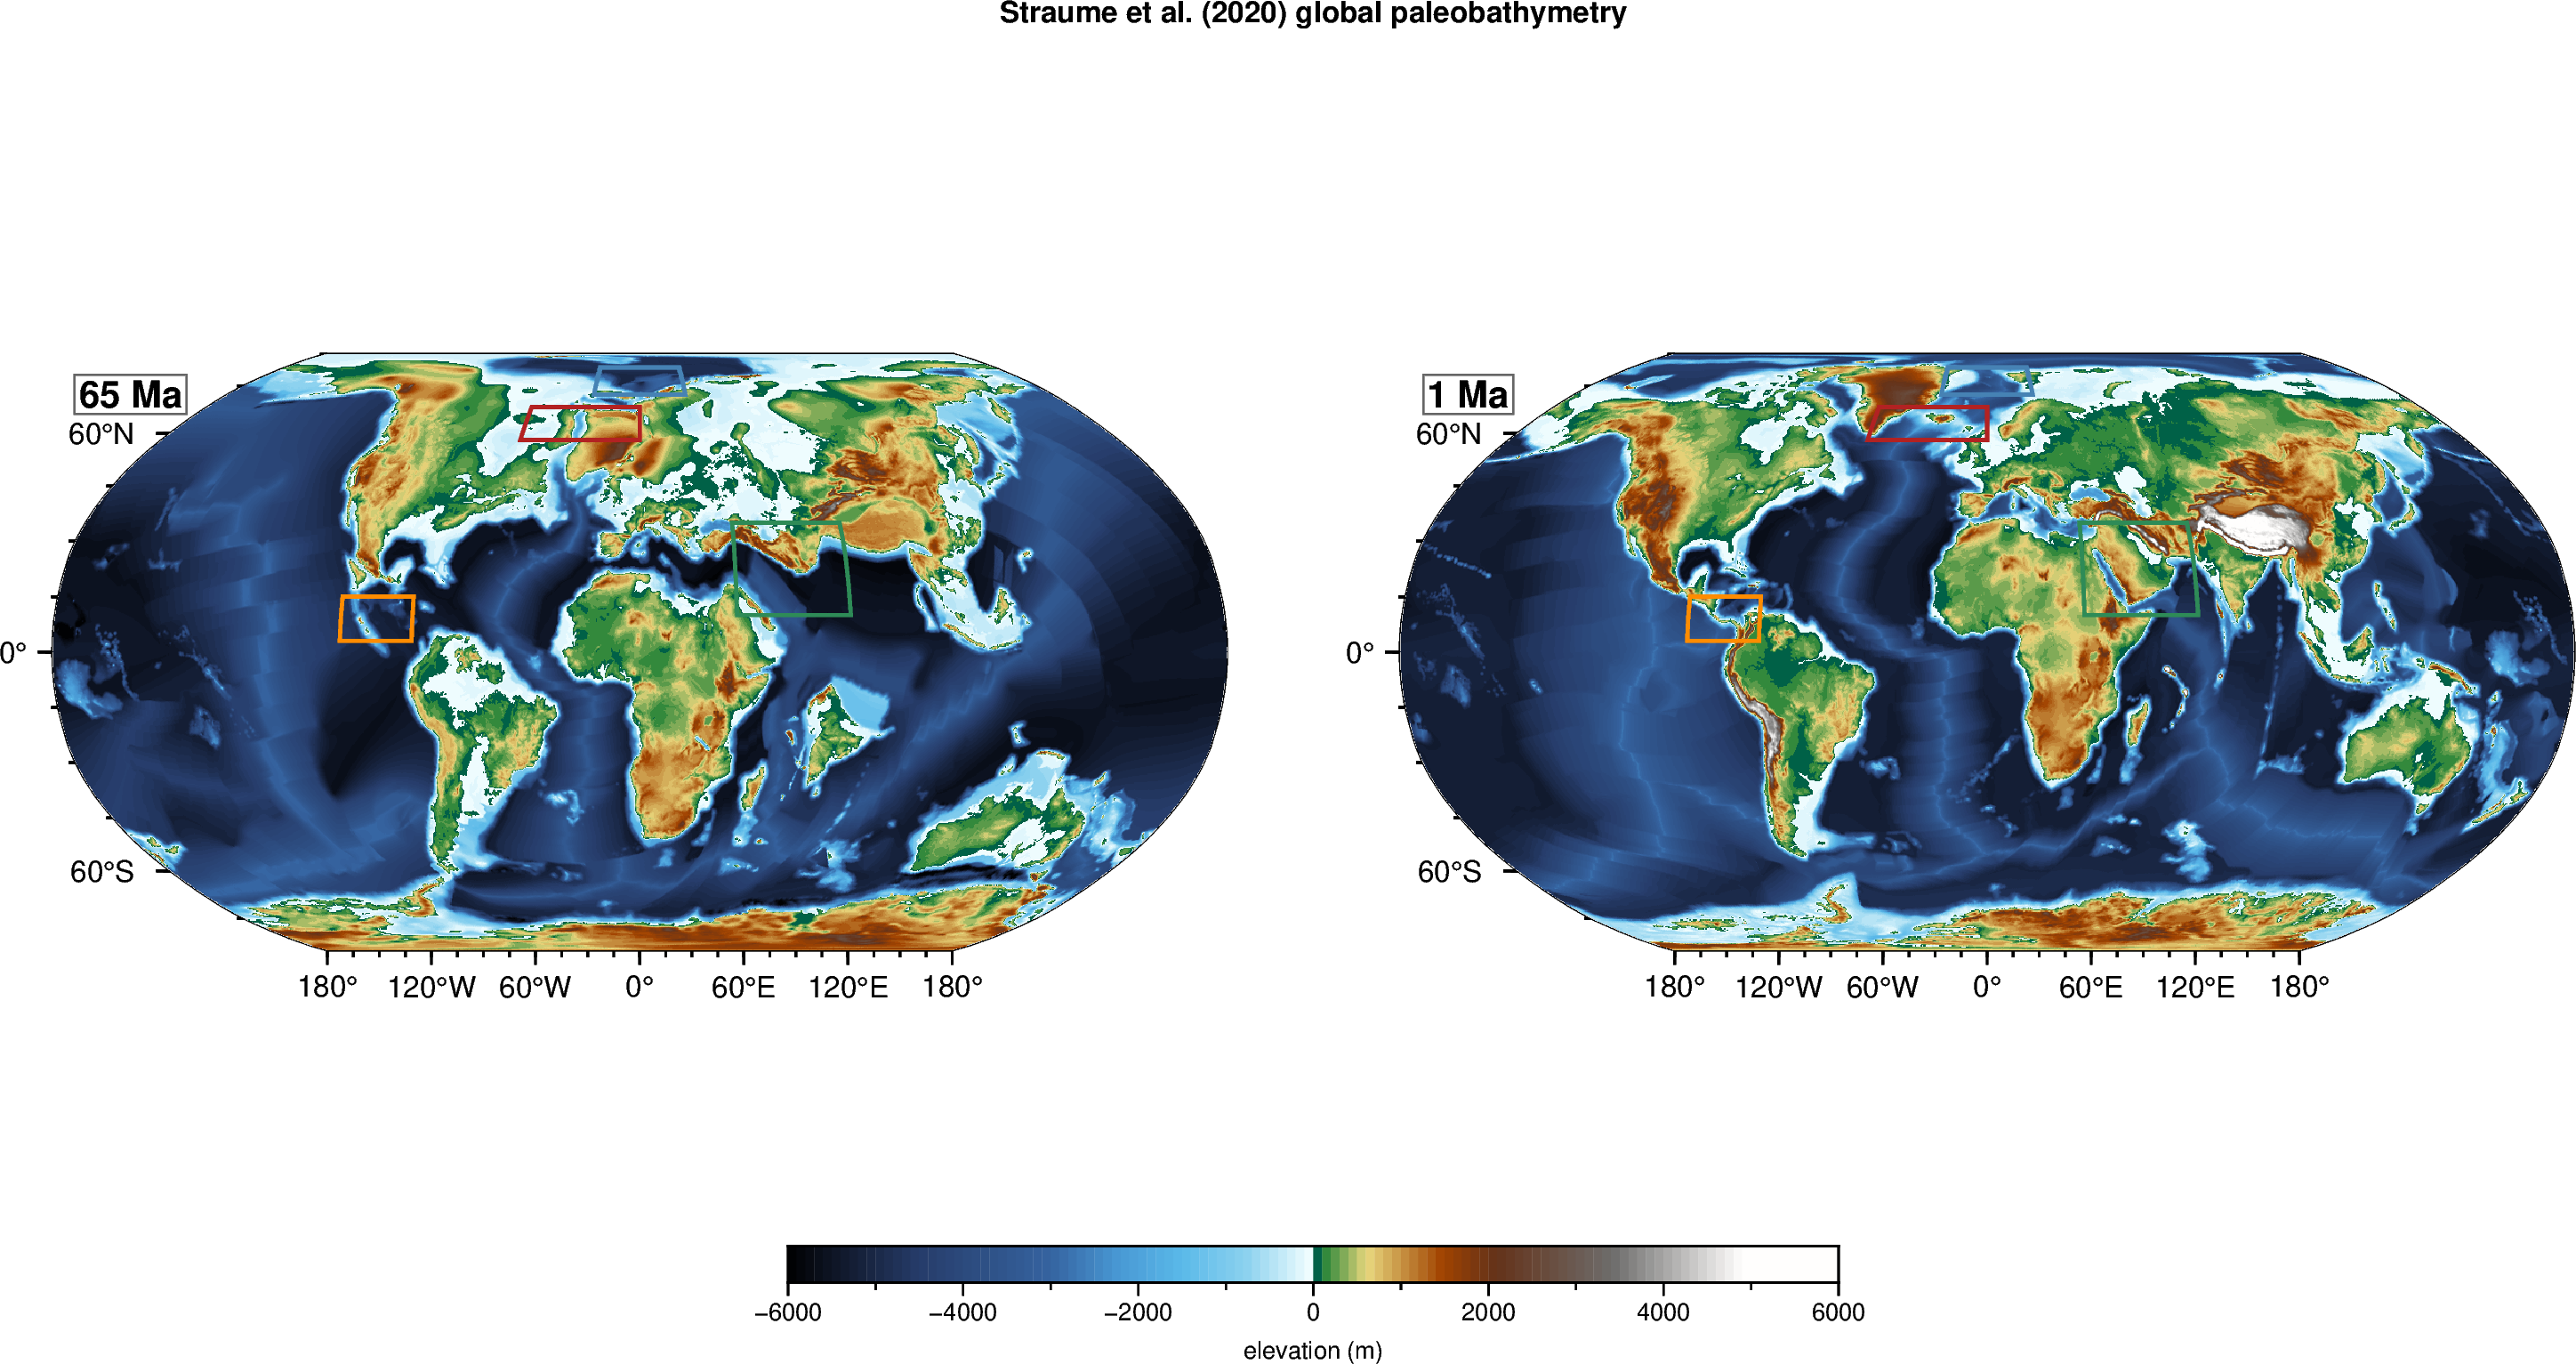

In [4]:
def box_outline(lon_range, lat_range, n=25):
    """Corner-to-corner polygon of a lon/lat box, densified so it follows map curvature."""
    lo0, lo1 = lon_range
    la0, la1 = lat_range
    top = list(zip(np.linspace(lo0, lo1, n), [la1] * n))
    right = list(zip([lo1] * n, np.linspace(la1, la0, n)))
    bottom = list(zip(np.linspace(lo1, lo0, n), [la0] * n))
    left = list(zip([lo0] * n, np.linspace(la0, la1, n)))
    pts = top + right + bottom + left
    return [p[0] for p in pts], [p[1] for p in pts]


fig = pygmt.Figure()
pygmt.makecpt(cmap="geo", series=[-6000, 6000, 100], background="o")
with fig.subplot(nrows=1, ncols=2, figsize=("24c", "8.5c"), margins=["0.6c", "1.2c"],
                  title="Straume et al. (2020) global paleobathymetry"):
    for panel_i, age in enumerate([65.0, 1.0]):
        with fig.set_panel(panel=panel_i):
            grid = load_grid(age).isel(lat=slice(None, None, 3), lon=slice(None, None, 3))
            fig.basemap(region=REGION, projection="N?", frame="af")
            fig.grdimage(grid=grid)
            for name, box in GATEWAYS.items():
                lons, lats = box_outline(box["lon"], box["lat"])
                fig.plot(x=lons, y=lats, pen=f"1p,{GATEWAY_COLOURS[name]}", close=True)
            fig.text(text=f"{age:.0f} Ma", position="TL", offset="0.25c/-0.25c", justify="TL",
                      font="10p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
fig.colorbar(frame="af+lelevation (m)", position="JBC+w10c/0.35c+h+o0/1.4c")
fig.savefig(OUTPUT_DIR / "T71_global_context.png", dpi=150)
fig.show(width=1050)


**What this shows.** At 65 Ma the four boxed regions already look geologically distinct from today: the Greenland-Scotland Ridge box sits astride a still-narrow, newly-opening North Atlantic; the Central American Seaway box is wide open ocean between two separate continents; the Tethyan Seaway box still carries a broad marine corridor north of a not-yet-collided India/Arabia. By 1 Ma all four have reorganised into essentially their modern configuration. The next two sections unpack *how* that reorganisation happened -- first mechanistically (&sect;3), then quantitatively through the full 65 Myr record (&sect;4).

## 3. Reconstructing the tectonic mechanism at 34 Ma

The Eocene-Oligocene transition (~34 Ma) is a genuinely major, independently well-established Cenozoic boundary -- the onset of large-scale Antarctic glaciation -- and it falls inside a period when all four gateways were undergoing active tectonic change. Here `gplately` reconstructs Seton et al. (2012)'s plate boundaries at this one age and overlays them directly on Straume et al.'s real, independently-derived bathymetry for each gateway region, to check whether the two agree on mechanism.

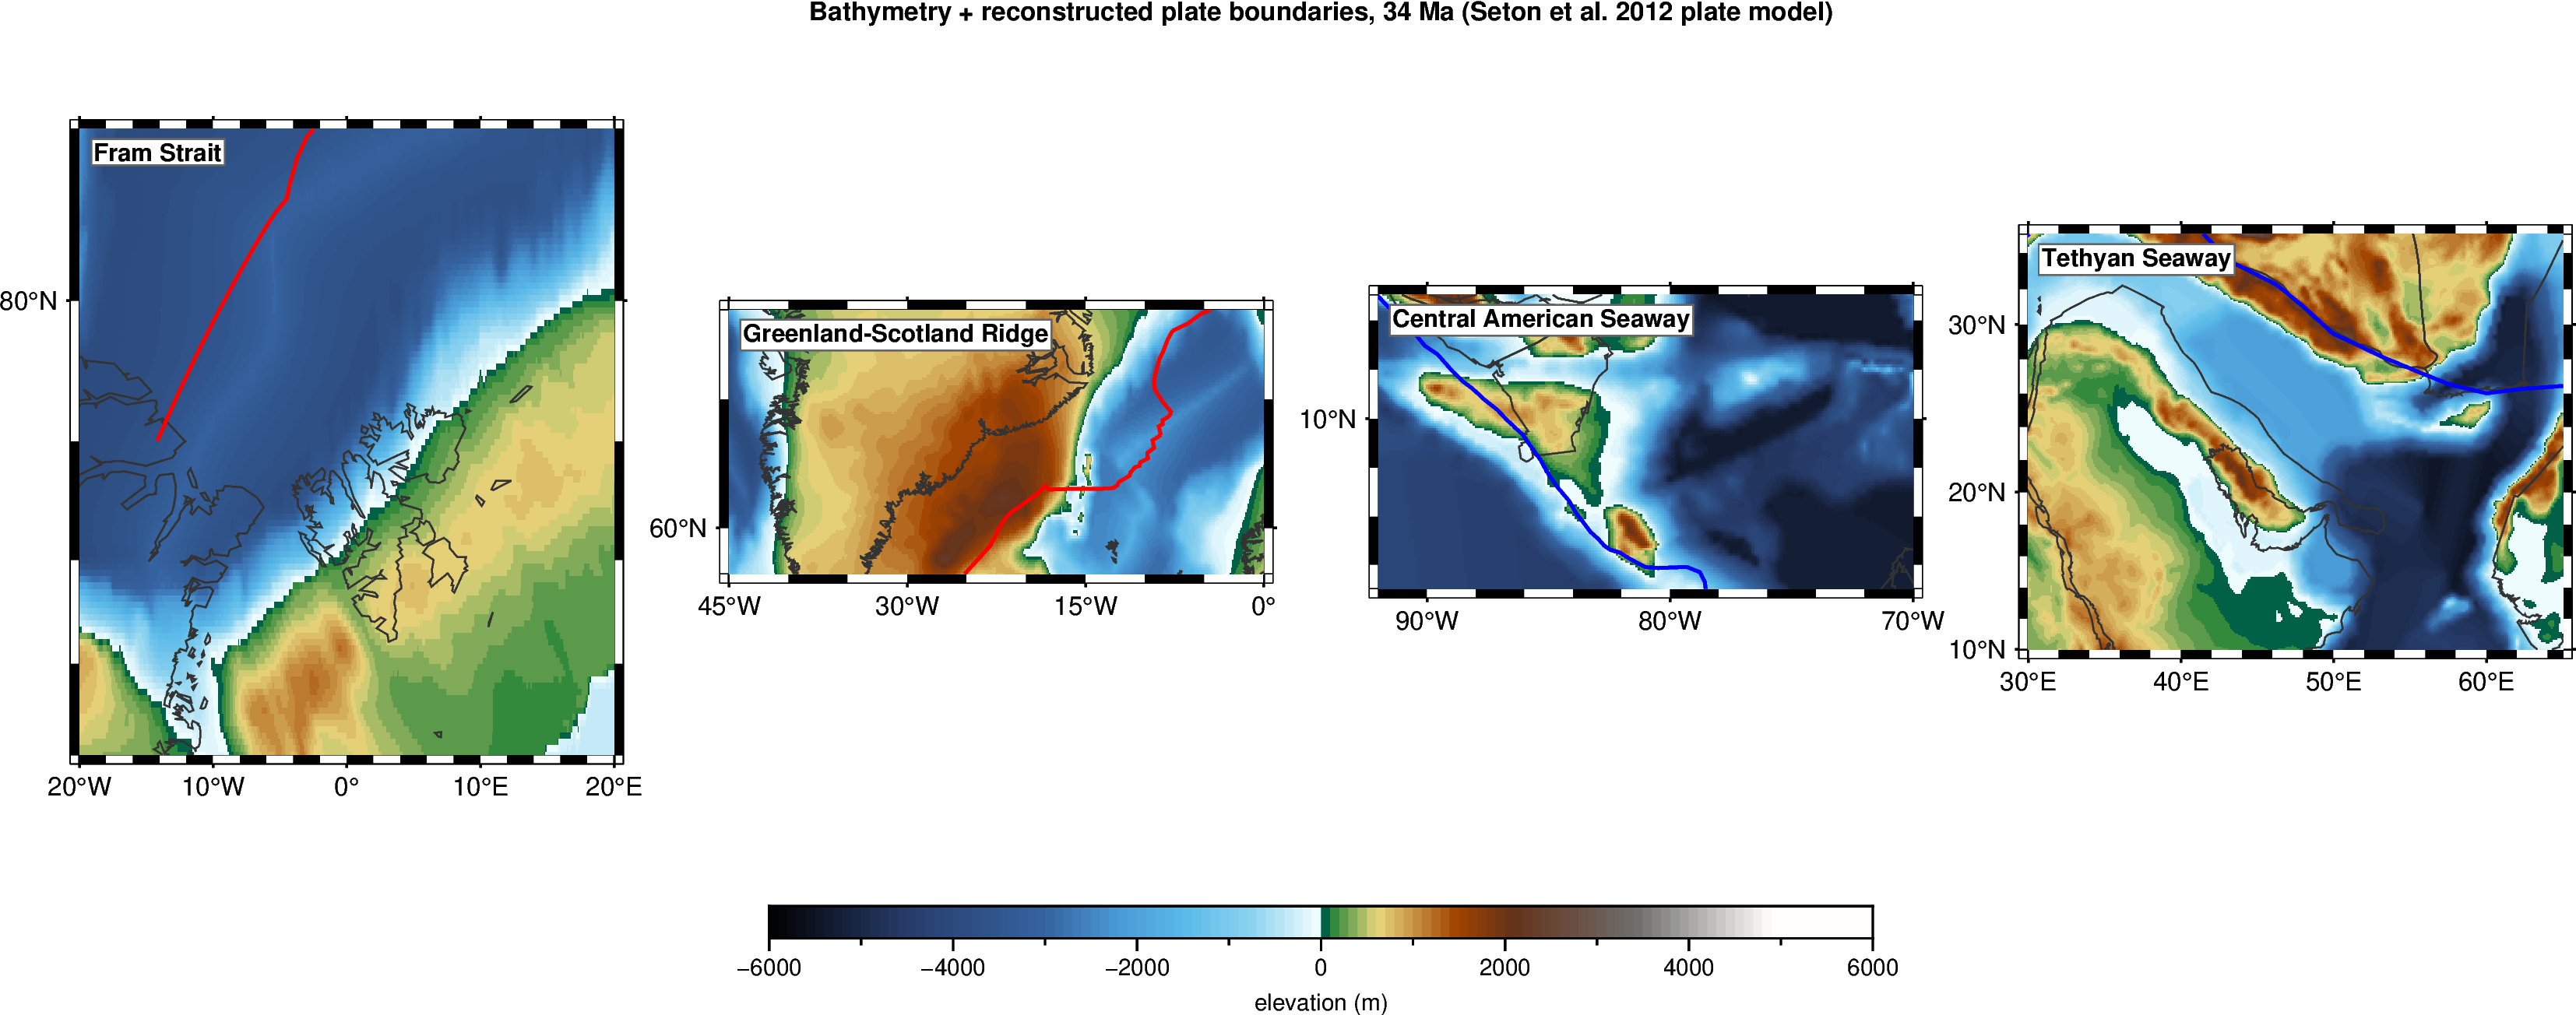

In [5]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gm = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    COBs=model.get_COBs(),
    time=SNAPSHOT_AGE,
    plot_engine=gplately.PygmtPlotEngine(),
)

snap = load_grid(SNAPSHOT_AGE)

fig = pygmt.Figure()
pygmt.makecpt(cmap="geo", series=[-6000, 6000, 100], background="o")
with fig.subplot(nrows=1, ncols=4, figsize=("27c", "7.5c"), margins=["0.4c", "0.3c"],
                  title=f"Bathymetry + reconstructed plate boundaries, {SNAPSHOT_AGE:.0f} Ma "
                        "(Seton et al. 2012 plate model)"):
    for panel_i, (name, box) in enumerate(GATEWAYS.items()):
        region = [box["lon"][0], box["lon"][1], box["lat"][0], box["lat"][1]]
        sub = snap.sel(lon=slice(*box["lon"]), lat=slice(*box["lat"]))
        with fig.set_panel(panel=panel_i):
            fig.basemap(region=region, projection="M?", frame="af")
            fig.grdimage(grid=sub)
            gm.plot_coastlines(fig, fill=None, pen="0.5p,gray20")
            gm.plot_ridges(fig, pen="1.1p,red")
            gm.plot_transforms(fig, pen="0.7p,darkorange")
            gm.plot_trenches(fig, pen="1.1p,blue")
            fig.text(text=name, position="TL", offset="0.15c/-0.15c", justify="TL",
                      font="7.5p,Helvetica-Bold,black", fill="white", pen="0.4p,gray40")
fig.colorbar(frame="af+lelevation (m)", position="JBC+w12c/0.35c+h+o0/1.3c")
fig.savefig(OUTPUT_DIR / "T71_gateway_tectonics.png", dpi=150)
fig.show(width=1050)


**What this shows.** Red = reconstructed mid-ocean ridge, orange = transform fault, blue = subduction zone (all Seton et al. 2012, reconstructed to 34 Ma with `gplately`); the grey outline is the reconstructed coastline. The plate boundaries line up with the bathymetric structure Straume et al. independently derived, at each of the four gateways, in a way that is mechanistically sensible: a mid-ocean ridge runs through the Fram Strait / Greenland-Scotland Ridge system (both are actively spreading segments of the same Arctic-Atlantic ridge system at 34 Ma, consistent with these being gateways created by seafloor spreading), a subduction zone borders the Central American Seaway (the same subduction system that eventually raised the Panama isthmus), and a subduction/collision zone runs along the northern edge of the Tethyan Seaway box (the early stages of the Arabia-Eurasia convergence that eventually pinches the corridor shut). None of this was fitted to match Straume's grids -- Seton et al. (2012) is an independent plate-circuit reconstruction, and Straume et al.'s own bathymetry model-building did not use `gplately`. The agreement is a genuine cross-check, not a tautology.

## 4. Quantifying gateway evolution through time

For each gateway box, at all 15 available ages: the mean elevation (m; negative = submerged on average) and the percent of grid cells below sea level. This turns four qualitative "before/after" snapshots into an actual 65 Myr time series.

In [6]:
records = []
for age in AGES:
    grid = load_grid(age)
    for name, box in GATEWAYS.items():
        sub = grid.sel(lon=slice(*box["lon"]), lat=slice(*box["lat"])).values
        records.append({
            "gateway": name, "age": age,
            "mean_elev_m": float(np.nanmean(sub)),
            "pct_submerged": float(np.mean(sub < 0) * 100),
        })
    grid.close()

gw_ts = pd.DataFrame(records).sort_values(["gateway", "age"])
print(gw_ts.pivot(index="age", columns="gateway", values="mean_elev_m").round(0).to_string())


gateway  Central American Seaway  Fram Strait  Greenland-Scotland Ridge  Tethyan Seaway
age                                                                                    
1.0                      -2092.0      -1829.0                   -1365.0          -373.0
5.0                      -2511.0      -1542.0                   -1200.0          -430.0
10.0                     -2791.0      -1395.0                    -795.0          -472.0
15.0                     -2965.0      -1321.0                    -574.0          -483.0
20.0                     -3028.0      -1322.0                    -536.0          -460.0
25.0                     -2854.0      -1225.0                    -449.0          -623.0
30.0                     -2812.0      -1135.0                    -341.0          -813.0
34.0                     -2810.0      -1396.0                    -264.0          -964.0
35.0                     -2820.0      -1408.0                    -263.0          -997.0
40.0                     -2830.0

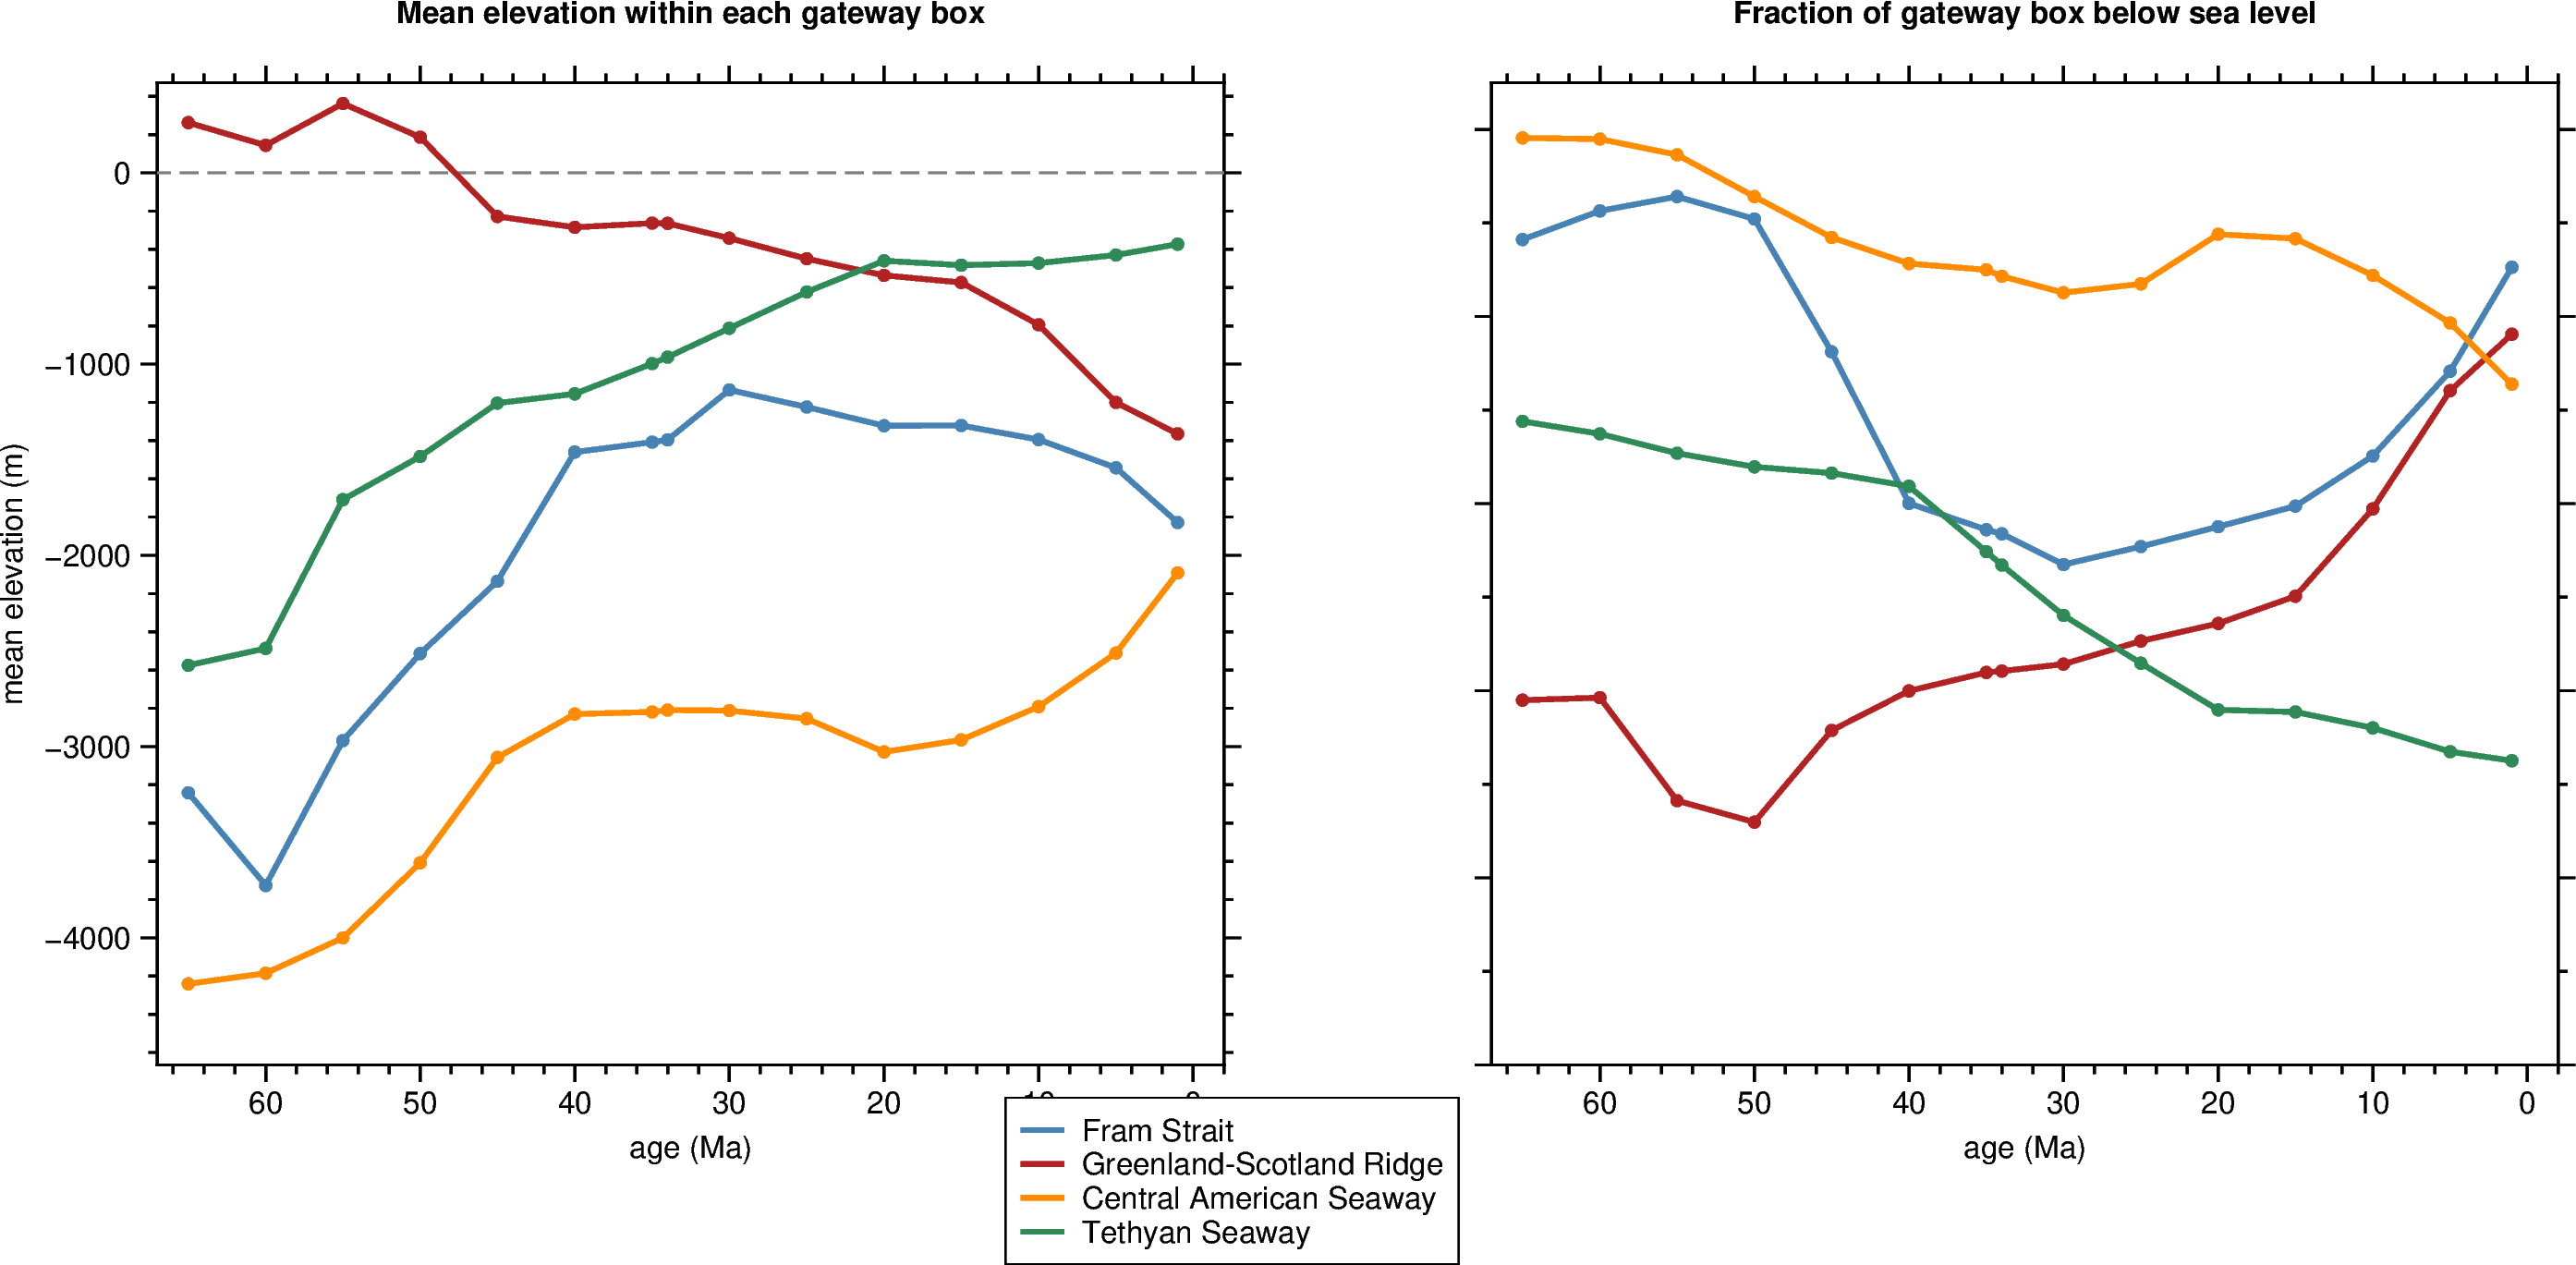

In [7]:
fig = pygmt.Figure()
with fig.subplot(nrows=1, ncols=2, figsize=("22c", "9c"), margins=["1c", "0.6c"]):
    with fig.set_panel(panel=0):
        # x-axis: age increases right-to-left (old on the left, present on the right),
        # the standard paleoclimate convention -- achieved with a negative-width-only
        # projection (auto-fit "X-?/?", flipping x but not y) rather than a reversed
        # -R, which GMT rejects. A bare "X-?" (single token) flips BOTH axes, not just x.
        region = [-2, 67, gw_ts["mean_elev_m"].min() * 1.1, max(gw_ts["mean_elev_m"].max() * 1.3, 200)]
        fig.basemap(region=region, projection="X-?/?",
                    frame=["WSne+tMean elevation within each gateway box", "xaf+lage (Ma)",
                           "yaf+lmean elevation (m)"])
        fig.plot(x=[-2, 67], y=[0, 0], pen="0.6p,gray50,-")
        for name in GATEWAYS:
            sub = gw_ts[gw_ts["gateway"] == name]
            fig.plot(x=sub["age"], y=sub["mean_elev_m"], pen=f"1.4p,{GATEWAY_COLOURS[name]}")
            fig.plot(x=sub["age"], y=sub["mean_elev_m"], style="c0.12c", fill=GATEWAY_COLOURS[name])
    with fig.set_panel(panel=1):
        region = [-2, 67, 0, 105]
        fig.basemap(region=region, projection="X-?/?",
                    frame=["wSne+tFraction of gateway box below sea level", "xaf+lage (Ma)", "yaf+l% submerged"])
        for name in GATEWAYS:
            sub = gw_ts[gw_ts["gateway"] == name]
            fig.plot(x=sub["age"], y=sub["pct_submerged"], pen=f"1.4p,{GATEWAY_COLOURS[name]}", label=name)
            fig.plot(x=sub["age"], y=sub["pct_submerged"], style="c0.12c", fill=GATEWAY_COLOURS[name])
        fig.legend(position="JBL+o0.3c", box="+gwhite+p0.5p")
fig.savefig(OUTPUT_DIR / "T71_gateway_timeseries.png", dpi=150)
fig.show(width=1050)


**What this shows.** Three of the four gateways shoal (become less deeply submerged) from 65 Ma to the present, and one moves the opposite way:

- **Central American Seaway** and **Tethyan Seaway** both shoal substantially -- CAS from a box-mean elevation of roughly -4240 m (65 Ma) to -2090 m (1 Ma), Tethyan from roughly -2580 m to -370 m -- consistent with both being progressively closed by active convergence: the subduction system bordering Central America (&sect;3) and the Arabia-Eurasia collision bordering the Tethyan box. The *exact* timing of Central American Seaway's final closure remains an active area of debate in the literature (see &sect;5); this box-mean curve is consistent with progressive shoaling, not a verdict on that debate.
- **Greenland-Scotland Ridge** uniquely moves the other way: its box-mean elevation starts *above* sea level on average (+100 to +360 m across 55-65 Ma -- more land than sea in this box in the early Cenozoic) and subsides to roughly -1400 m by the present. That is the textbook ridge-subsidence signature: newly created oceanic crust starts warm and buoyant near a spreading axis and cools and sinks as it ages and spreads away from it -- consistent with &sect;3's reconstructed mid-ocean ridge running directly through this box.
- **Fram Strait** shoals overall (roughly -3200 to -3700 m in the Paleocene to roughly -1300 to -1800 m from the mid-Miocene onward) but non-monotonically, with its deepest box-mean value at 60 Ma rather than 65 Ma. This is the least clean of the four trajectories, and is a plausible symptom of the &sect;4 configuration cell's disclosed limitation: a fixed present-day-frame box mixes young spreading-centre oceanic crust with drifting continental-shelf material in changing proportions over 65 Myr, so its mean reflects more than one process at once.

None of these curves are smooth monotonic trends -- real tectonic and grid-resolution noise is visible throughout -- which is itself a useful reminder that a 15-point, 0.1&deg;-grid-box-mean time series is a coarse instrument, not a publication-grade gateway-depth reconstruction.

## 5. What this does -- and does not -- show

This notebook establishes two things reasonably robustly: (1) Straume et al.'s independently-derived bathymetry and an independently-reconstructed plate-boundary model agree, at a first-order tectonic-mechanism level, on *why* each gateway's depth changed when it did (&sect;3); and (2) a simple regional box-mean statistic, computed consistently across all 15 available ages, recovers each gateway's broad qualitative history -- ridge subsidence, continued spreading, and two convergence-driven closures (&sect;4).

It does **not** establish precise closure ages, sill depths, or flow rates -- those require the actual ocean-circulation modelling Straume et al. (2020) themselves carried out (and which this notebook does not attempt to reproduce), plus finer plate-boundary detail than the Seton et al. (2012) parent model provides for these specific straits. The Central American Seaway's exact final-closure timing in particular remains genuinely disputed in the literature (compare, e.g., Montes et al. 2015's ~10-13 Ma estimate against later isthmus-formation arguments extending well into the Pliocene) -- this notebook's box-mean curve is consistent with progressive shoaling, not a verdict on that debate.

The broader point carries beyond these four gateways: Cenozoic ocean-gateway reorganisation is widely discussed in the paleoceanographic literature as one plausible contributor to first-order circulation changes over this interval (e.g. the deepening of North Atlantic-Arctic connections alongside the broadly contemporaneous onset of major Antarctic glaciation near the Eocene-Oligocene boundary) -- this notebook shows the *gateways themselves* changing shape and depth on a real, physically grounded timeline; it does not attempt to adjudicate the causal ocean-circulation arguments built on top of that timeline.

## Extend this

- **Use the actual within-box minimum, not the mean, as a sill-depth proxy.** Percent-submerged and mean elevation are robust but blunt; the true rate-limiting factor for deep-water exchange through a strait is usually its *shallowest* connecting point (the sill), which a coarse box mean can under- or over-estimate depending on how much of the box is genuinely part of the strait versus adjacent shelf.
- **Narrow the Central American Seaway and Tethyan Seaway boxes, or make them time-varying**, using the &sect;3 reconstructed plate boundaries to track the actual corridor position at each age instead of holding a fixed present-day-frame box -- the biggest disclosed limitation in &sect;4.
- **Compare against an actual ocean model.** T69's cGENIE workflow is a template for driving an Earth-system model with a paleobathymetry boundary condition -- Straume et al.'s own grids are a natural input for exactly that kind of follow-up experiment.
- **Push further back in time.** Straume et al. (2020)'s grids stop at 65 Ma; T69's Devonian FOAM climatology (420-360 Ma) is a template for finding boundary-condition datasets much deeper in the Phanerozoic.
- **Swap in the Zahirovic et al. (2022) paleomagnetic-frame paleobathymetry grids.** Replace the Straume et al. (2020) grids with paleobathymetry grids in a paleomagnetic reference frame, based on the plate model of Zahirovic et al. (2022) and produced by combining pyBacktrack (for ocean floor that still exists today) with forward-modelled paleobathymetry (for now-subducted ocean floor). Grids: https://repo.gplates.org/webdav/PlateModel_Age_SR_Grids/Zahirovic_etal_2022_GDJ/02_AgegridsUsingTopologies/PaleomagneticFrame/PaleobathymetryGrids/pybacktrack/GDH1/. Workflow described in the pyBacktrack 1.5 documentation's [merging-with-traditional-paleobathymetry section](https://pybacktrack.readthedocs.io/en/stable/pybacktrack_paleo_bathymetry.html#merging-with-traditional-paleobathymetry).

## Related notebooks

- **T69** -- Devonian paleogeography and climatology (FOAM/cGENIE). Another paleoclimate boundary-condition dataset reconstructed with the same `gplately` + `pygmt` combination, at much greater age.
- **T70** -- PhanSST deep-time SST proxy reconstruction. Another real, independently-collected dataset reconstructed to a specific paleo-age with `gplately`.
- **T51** -- Also uses `plate_model_manager`'s Young et al. (2022) dynamic-topography model; a comparable case of a specific published Earth-evolution product paired with `gplately` reconstruction.

## References

Straume, E.O., Gaina, C., Medvedev, S., Nummelin, A., Schnabel, C., Hass, C. & de Steur, L. (2020). Global Cenozoic paleobathymetry with a focus on the Northern Hemisphere oceanic gateways. *Global and Planetary Change* 194, 103297. https://doi.org/10.1016/j.gloplacha.2020.103297. Data (v2.0): Zenodo, https://doi.org/10.5281/zenodo.4193576, CC BY 4.0.

Seton, M., M&uuml;ller, R.D., Zahirovic, S. et al. (2012). Global continental and ocean basin reconstructions since 200 Ma. *Earth-Science Reviews* 113(3-4), 212-270. https://doi.org/10.1016/j.earscirev.2012.03.002

Mather, B.R., M&uuml;ller, R.D., Zahirovic, S., et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10. https://doi.org/10.1002/gdj3.185

Montes, C., Cardona, A., Jaramillo, C. et al. (2015). Middle Miocene closure of the Central American Seaway. *Science* 348(6231), 226-229. https://doi.org/10.1126/science.aaa2815 (cited in &sect;5 as one estimate in an actively debated timeline, not as settled fact).

Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. https://doi.org/10.1002/gdj3.146
